### First we generate language n-grams

In [41]:
from pathlib import Path
from collections import Counter

import pandas as pd
from nltk.util import ngrams

In [ ]:
def generate_character_ngrams(text, n=3):
    text = "_".join(text.lower().split())

    # Generate overlapping character n-grams and count their frequencies
    return Counter(
        ''.join(g)
        for g in ngrams(text, n)
    )

In [27]:
OUTPUT_DIR = Path("../data/ngrams")
OUTPUT_DIR.mkdir(exist_ok=True)

for language, text in corpora.items():
    counts = generate_character_ngrams(text, 3)

    df = (
        pd.DataFrame(
            counts.items(),
            columns=["ngram", "frequency"]
        )
        .sort_values("frequency", ascending=False)
        .reset_index(drop=True)
    )

    df.to_csv(
        OUTPUT_DIR / f"{language}_character_trigrams.csv",
        index=False
    )

    print(f"Saved {language}")

Saved Bikol
Saved Cebuano
Saved English
Saved Hiligaynon
Saved Ilocano
Saved Kapampangan
Saved Pangasinense
Saved Spanish
Saved Tagalog
Saved Waray


### Determining how many trigrams are taken into account

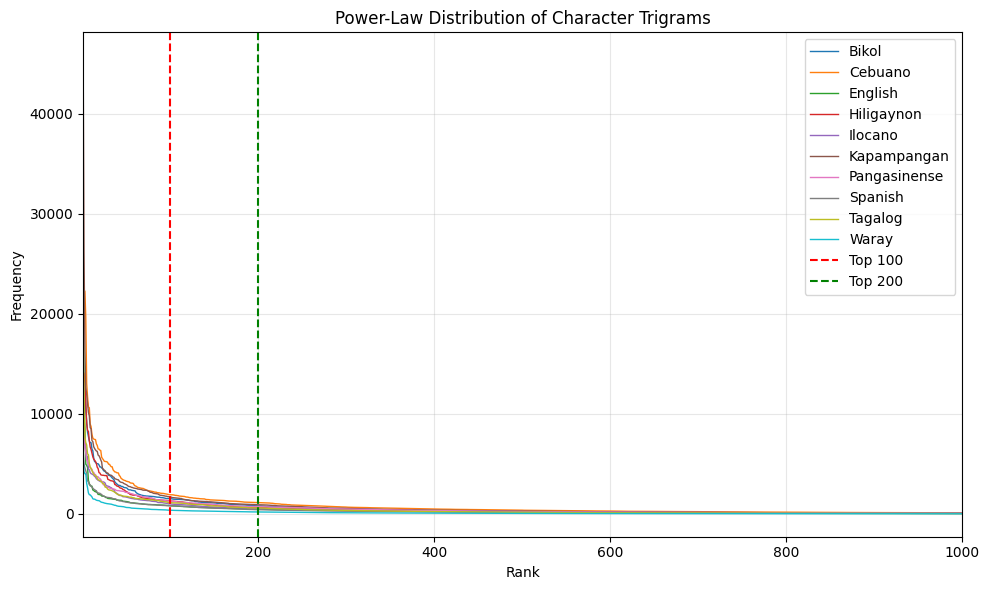

In [40]:
import matplotlib.pyplot as plt

MAX_RANK = 1000

plt.figure(figsize=(10, 6))

for language, text in corpora.items():
    counts = generate_character_ngrams(text, 3)

    frequencies = sorted(counts.values(), reverse=True)[:MAX_RANK]

    plt.plot(
        range(1, len(frequencies) + 1),
        frequencies,
        linewidth=1,
        label=language
    )

plt.axvline(100, color='red', linestyle='--', label='Top 100')
plt.axvline(200, color='green', linestyle='--', label='Top 200')

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Power-Law Distribution of Character Trigrams")
plt.xlim(1, MAX_RANK)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
from pathlib import Path
import pandas as pd
import numpy as np

NGRAM_DIR = Path("../data/ngrams")

TOP_K = 100

language_vectors = {}
vocabulary = set()

# Read the top-k trigrams from every language
for file in NGRAM_DIR.glob("*_character_trigrams.csv"):
    language = file.stem.replace("_character_trigrams", "")

    df = (
        pd.read_csv(file,na_filter=False)
        .head(TOP_K)
    )

    freq_dict = dict(zip(df["ngram"], df["frequency"]))

    language_vectors[language] = freq_dict
    vocabulary.update(freq_dict.keys())

vocabulary = sorted(vocabulary)

print(f"{len(language_vectors)} languages")
print(f"{len(vocabulary)} unique trigrams")

10 languages
416 unique trigrams


In [63]:
aligned_vectors = {}

for language, freq_dict in language_vectors.items():
    aligned_vectors[language] = np.array([
        freq_dict.get(trigram, 0)
        for trigram in vocabulary
    ])

In [64]:
from sklearn.metrics.pairwise import cosine_similarity

languages = list(aligned_vectors.keys())

matrix = np.vstack([
    aligned_vectors[lang]
    for lang in languages
])

cosine_matrix = cosine_similarity(matrix)

cosine_df = pd.DataFrame(
    cosine_matrix,
    index=languages,
    columns=languages
)

cosine_df

,Bikol,Cebuano,English,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Spanish,Tagalog,Waray
Bikol,1.000000,0.754973,0.105476,0.720740,0.383800,0.488108,0.673207,0.130321,0.718196,0.733554
Cebuano,0.754973,1.000000,0.109293,0.889493,0.337257,0.563663,0.517878,0.115325,0.841647,0.717415
English,0.105476,0.109293,1.000000,0.104279,0.062904,0.124401,0.149114,0.114377,0.128152,0.088842
Hiligaynon,0.720740,0.889493,0.104279,1.000000,0.352590,0.535793,0.499201,0.102283,0.822082,0.758534
Ilocano,0.383800,0.337257,0.062904,0.352590,1.000000,0.272462,0.449432,0.123843,0.336011,0.358884
Kapampangan,0.488108,0.563663,0.124401,0.535793,0.272462,1.000000,0.382953,0.065336,0.729665,0.281373
Pangasinense,0.673207,0.517878,0.149114,0.499201,0.449432,0.382953,1.000000,0.180394,0.498926,0.592472
Spanish,0.130321,0.115325,0.114377,0.102283,0.123843,0.065336,0.180394,1.000000,0.086548,0.118382
Tagalog,0.718196,0.841647,0.128152,0.822082,0.336011,0.729665,0.498926,0.086548,1.000000,0.568986
Waray,0.733554,0.717415,0.088842,0.758534,0.358884,0.281373,0.592472,0.118382,0.568986,1.000000


In [65]:
def dice_similarity(x, y):
    x = x > 0
    y = y > 0

    intersection = np.sum(x & y)

    return (2 * intersection) / (np.sum(x) + np.sum(y))

In [66]:
dice_matrix = np.zeros((len(languages), len(languages)))

for i, lang1 in enumerate(languages):
    for j, lang2 in enumerate(languages):
        dice_matrix[i, j] = dice_similarity(
            aligned_vectors[lang1],
            aligned_vectors[lang2]
        )

dice_df = pd.DataFrame(
    dice_matrix,
    index=languages,
    columns=languages
)

dice_df

,Bikol,Cebuano,English,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Spanish,Tagalog,Waray
Bikol,1.00,0.64,0.09,0.66,0.45,0.44,0.48,0.20,0.60,0.64
Cebuano,0.64,1.00,0.09,0.71,0.43,0.48,0.48,0.18,0.64,0.62
English,0.09,0.09,1.00,0.10,0.13,0.10,0.19,0.23,0.13,0.11
Hiligaynon,0.66,0.71,0.10,1.00,0.43,0.41,0.48,0.15,0.61,0.66
Ilocano,0.45,0.43,0.13,0.43,1.00,0.41,0.56,0.19,0.47,0.43
Kapampangan,0.44,0.48,0.10,0.41,0.41,1.00,0.48,0.12,0.52,0.38
Pangasinense,0.48,0.48,0.19,0.48,0.56,0.48,1.00,0.21,0.50,0.52
Spanish,0.20,0.18,0.23,0.15,0.19,0.12,0.21,1.00,0.15,0.16
Tagalog,0.60,0.64,0.13,0.61,0.47,0.52,0.50,0.15,1.00,0.53
Waray,0.64,0.62,0.11,0.66,0.43,0.38,0.52,0.16,0.53,1.00


In [67]:
def extended_jaccard(x, y):
    numerator = np.dot(x, y)

    denominator = (
        np.dot(x, x)
        + np.dot(y, y)
        - numerator
    )

    return numerator / denominator

In [68]:
jaccard_matrix = np.zeros((len(languages), len(languages)))

for i, lang1 in enumerate(languages):
    for j, lang2 in enumerate(languages):
        jaccard_matrix[i, j] = extended_jaccard(
            aligned_vectors[lang1],
            aligned_vectors[lang2]
        )

jaccard_df = pd.DataFrame(
    jaccard_matrix,
    index=languages,
    columns=languages
)

jaccard_df

,Bikol,Cebuano,English,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Spanish,Tagalog,Waray
Bikol,1.000000,0.562029,0.045013,0.558769,0.213361,0.289229,0.457590,0.046755,0.525521,0.234934
Cebuano,0.562029,1.000000,0.037582,0.692016,0.151240,0.389497,0.261902,0.031860,0.549229,0.164016
English,0.045013,0.037582,1.000000,0.047148,0.031578,0.039560,0.077265,0.058440,0.063802,0.038572
Hiligaynon,0.558769,0.692016,0.047148,1.000000,0.201310,0.307958,0.316593,0.039163,0.677672,0.273067
Ilocano,0.213361,0.151240,0.031578,0.201310,1.000000,0.110029,0.289448,0.058090,0.199774,0.149008
Kapampangan,0.289229,0.389497,0.039560,0.307958,0.110029,1.000000,0.167872,0.016259,0.407525,0.052837
Pangasinense,0.457590,0.261902,0.077265,0.316593,0.289448,0.167872,1.000000,0.084843,0.330691,0.261383
Spanish,0.046755,0.031860,0.058440,0.039163,0.058090,0.016259,0.084843,1.000000,0.037151,0.059039
Tagalog,0.525521,0.549229,0.063802,0.677672,0.199774,0.407525,0.330691,0.037151,1.000000,0.229414
Waray,0.234934,0.164016,0.038572,0.273067,0.149008,0.052837,0.261383,0.059039,0.229414,1.000000


In [69]:
def overlap_similarity(x, y):
    x = x > 0
    y = y > 0

    intersection = np.sum(x & y)

    return intersection / min(np.sum(x), np.sum(y))

In [70]:
overlap_matrix = np.zeros((len(languages), len(languages)))

for i, lang1 in enumerate(languages):
    for j, lang2 in enumerate(languages):
        overlap_matrix[i, j] = overlap_similarity(
            aligned_vectors[lang1],
            aligned_vectors[lang2]
        )

overlap_df = pd.DataFrame(
    overlap_matrix,
    index=languages,
    columns=languages
)

overlap_df

,Bikol,Cebuano,English,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Spanish,Tagalog,Waray
Bikol,1.00,0.64,0.09,0.66,0.45,0.44,0.48,0.20,0.60,0.64
Cebuano,0.64,1.00,0.09,0.71,0.43,0.48,0.48,0.18,0.64,0.62
English,0.09,0.09,1.00,0.10,0.13,0.10,0.19,0.23,0.13,0.11
Hiligaynon,0.66,0.71,0.10,1.00,0.43,0.41,0.48,0.15,0.61,0.66
Ilocano,0.45,0.43,0.13,0.43,1.00,0.41,0.56,0.19,0.47,0.43
Kapampangan,0.44,0.48,0.10,0.41,0.41,1.00,0.48,0.12,0.52,0.38
Pangasinense,0.48,0.48,0.19,0.48,0.56,0.48,1.00,0.21,0.50,0.52
Spanish,0.20,0.18,0.23,0.15,0.19,0.12,0.21,1.00,0.15,0.16
Tagalog,0.60,0.64,0.13,0.61,0.47,0.52,0.50,0.15,1.00,0.53
Waray,0.64,0.62,0.11,0.66,0.43,0.38,0.52,0.16,0.53,1.00
